# CTSM: learning time scores from samples alone

A notebook covering the upstream score estimator to help with the question "where do the score targets come from when there is no oracle?"

Conditional Time Score Matching (Yu, Klami, Hyvärinen, Korba, Chehab, ICML 2025) trains a network $s_\phi(x, t) \approx \partial_t \log p_t(x)$ (the time score) along a probability path) from samples alone.  The trick is the time-score analogue of Vincent's denoising trick:

- The marginal time score is intractable.  But conditioned on a data sample $z$, the Gaussian path $p_t(x|z) = \mathcal{N}(\alpha_t z, \sigma_t^2 I)$ has a closed-form conditional time score.
- Regressing on the conditional target (CTSM, Eq. 8) equals the intractable marginal objective up to a constant (Theorem 1), so the minimiser is the marginal time score:

   $s_\phi^*(x,t) = \mathbb{E}\bigl[\partial_t\log p_t(x|z) \,\big|\, x_t = x\bigr]
   = \partial_t\log p_t(x).$
   
- The payoff is the integrated **density-ratio identity** (Choi et al. 2022):
   $\log\tfrac{p_{t_1}(x)}{p_{t_0}(x)} = \int_{t_0}^{t_1} s_\phi(x,\tau)\,d\tau .$

In the parameter-flow programme this is the machinery behind
`CTSMJointScore`: identify the path index with a parameter-path coordinate and
the time score becomes the joint score $\partial_s \log p_{\theta(s)}(x)$
that `parameter_flow_loss` consumes as a frozen target.

We use a toy where everything is checkable: data $z \sim \mathcal{N}(1, 0.7^2)$
on a VP path, so the marginal $p_t = \mathcal{N}(\alpha_t\mu_1,\,
\alpha_t^2\sigma_1^2 + \sigma_t^2)$ — and its time score — are analytic.


In [18]:
import math

import matplotlib.pyplot as plt
import torch
from torch import nn

from nami import VPSchedule, ctsm_loss
from nami.components import SinusoidalTimeEmbedding
from nami.losses.score_matching import _conditional_time_score, _schedule_rates

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')
torch.manual_seed(11)
generator = torch.Generator().manual_seed(11)

schedule = VPSchedule(0.1, 8.0)
MU1, SIG1 = 1.0, 0.7


def marginal_logp(x, t):
    a, s = schedule.alpha(t), schedule.sigma(t)
    v = a**2 * SIG1**2 + s**2
    return (
        -0.5 * math.log(2 * math.pi)
        - 0.5 * torch.log(v)
        - (x - a * MU1) ** 2 / (2 * v)
    )


def marginal_time_score(x, t):
    t = t.detach().clone().requires_grad_(True)
    (g,) = torch.autograd.grad(marginal_logp(x, t).sum(), t)
    return g


### 1. The path: a family of marginals indexed by $t$

The VP path carries the data distribution $p_1$-ish (at $t=0$, where
$\alpha=1$) towards pure noise (at $t=1$).  Every vertical slice is a
marginal $p_t$; the time score measures how fast its log-density changes as
$t$ moves.


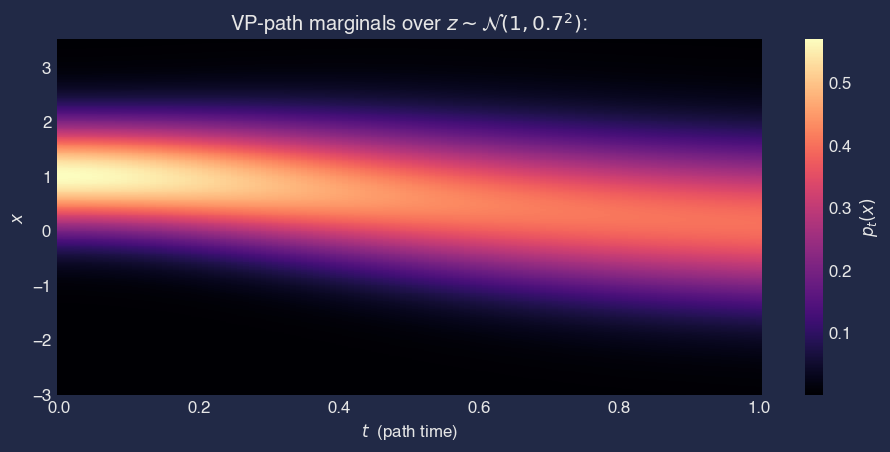

In [19]:
ts = torch.linspace(0.0, 1.0, 121)
grid = torch.linspace(-3.0, 3.5, 401)
ribbon = torch.stack(
    [torch.exp(marginal_logp(grid, torch.full_like(grid, t))) for t in ts.tolist()]
)

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
im = ax.pcolormesh(ts, grid, ribbon.T, cmap="magma", shading="auto")
ax.set_xlabel("$t$  (path time)")
ax.set_ylabel("$x$")
ax.set_title(
    r"VP-path marginals over $z \sim \mathcal{N}(1, 0.7^2)$:"
)
fig.colorbar(im, ax=ax, label="$p_t(x)$")
plt.show()


### 2. The denoising trick, visibly

At a fixed $t$, draw many $(z, \varepsilon)$ pairs and plot each pair's
**conditional** time score $\partial_t \log p_t(x_t|z)$ against where the
pair landed, $x_t$.  The cloud is wild — individual targets miss the marginal
by several hundred percent.  But their **conditional mean at each $x$** (the
binned line) sits exactly on the analytic marginal time score.  That
conditional mean is what squared-error regression converges to: Theorem 1 in
one picture.


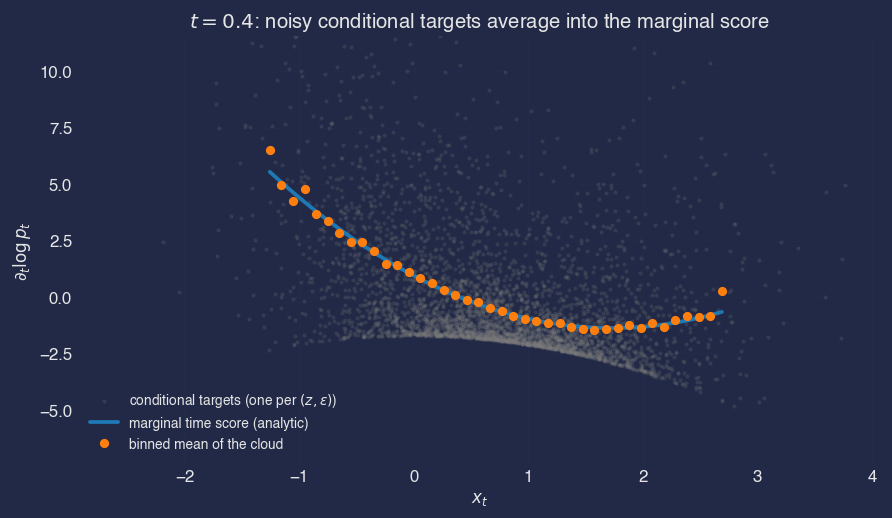

per-target RMS around the marginal: 2.70 (signal scale 1.61)


In [20]:
t_show = 0.4
n = 20000
z = MU1 + SIG1 * torch.randn(n, 1, generator=generator)
eps = torch.randn(n, 1, generator=generator)
tt = torch.full((n,), t_show)

a, s, a_dot, s_dot = _schedule_rates(schedule, tt)
x_t = (a.unsqueeze(-1) * z + s.unsqueeze(-1) * eps).squeeze(-1)
cond_target = _conditional_time_score(z, eps, a_dot, s, s_dot)

# bin the conditional targets in x and average
edges = torch.linspace(x_t.quantile(0.01), x_t.quantile(0.99), 41)
centres = 0.5 * (edges[:-1] + edges[1:])
idx = torch.bucketize(x_t, edges).clamp(1, len(edges) - 1) - 1
binned = torch.full_like(centres, torch.nan)
for b in range(len(centres)):
    sel = idx == b
    if sel.sum() > 50:
        binned[b] = cond_target[sel].mean()

xs = torch.linspace(centres[0], centres[-1], 201)
truth = marginal_time_score(xs, torch.full_like(xs, t_show))

fig, ax = plt.subplots(figsize=(8, 4.6), layout="constrained")
ax.scatter(x_t[:4000], cond_target[:4000], s=3, alpha=0.15, color="tab:gray",
           label="conditional targets (one per $(z,\\varepsilon)$)")
ax.plot(xs, truth, lw=2.5, color="tab:blue",
        label="marginal time score (analytic)")
ax.plot(centres, binned, "o", ms=5, color="tab:orange",
        label="binned mean of the cloud")
ax.set_xlabel("$x_t$")
ax.set_ylabel(r"$\partial_t \log p_t$")
ax.set_ylim(float(truth.min()) - 6, float(truth.max()) + 6)
ax.legend(fontsize=9)
ax.set_title(
    f"$t={t_show}$: noisy conditional targets average into the marginal score"
)
plt.show()

resid = cond_target - marginal_time_score(x_t, tt)
print(f"per-target RMS around the marginal: {resid.pow(2).mean().sqrt():.2f} "
      f"(signal scale {truth.abs().mean():.2f})")


### 3. Why the Eq. 20 weighting exists

The conditional-target variance is savagely $t$-dependent: it diverges where
$\sigma_t \to 0$ (the $\dot\sigma/\sigma$ terms).  Left unweighted, the
small-$t$ region dominates every gradient step with noise.  The time-score
normalisation $\lambda(t) \propto 1/\mathbb{E}[(\partial_t\log
p_t(x|z))^2]$ (closed form below) flattens the per-$t$ contribution — this is
`weighting="normalised"`, the default in `ctsm_loss`.


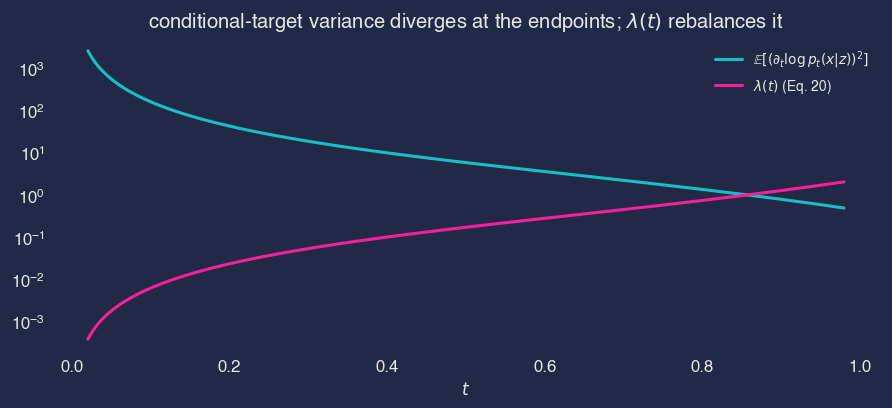

In [21]:
tt = torch.linspace(0.02, 0.98, 200)
a, s, a_dot, s_dot = _schedule_rates(schedule, tt)
m2 = MU1**2 + SIG1**2  # E||z||^2 for the toy
target_var = (a_dot / s) ** 2 * m2 + 2 * 1 * (s_dot / s) ** 2  # d = 1

fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
ax.semilogy(tt, target_var, lw=2, label=r"$\mathbb{E}[(\partial_t\log p_t(x|z))^2]$")
ax.semilogy(tt, 1.0 / target_var, lw=2, label=r"$\lambda(t)$ (Eq. 20)")
ax.set_xlabel("$t$")
ax.legend(fontsize=9)
ax.set_title("conditional-target variance diverges at the endpoints; "
             r"$\lambda(t)$ rebalances it")
plt.show()


### 4. Train with `ctsm_loss` — samples in, time scores out

No oracle anywhere in this loop: just data draws and the schedule.  Note the
loss plateaus well above zero — that floor is the irreducible conditional
variance (the cloud in §2), not a failure to fit.  Convergence shows up in the
*evaluations* below, not in the loss value.


step 0: ctsm loss 1.023
step 2000: ctsm loss 0.752
step 4000: ctsm loss 0.608
step 6000: ctsm loss 0.642


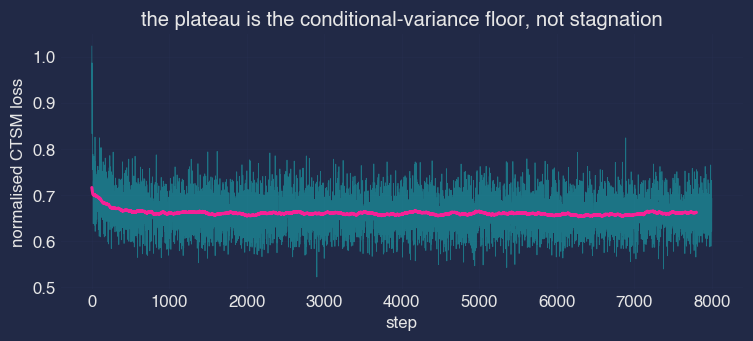

In [22]:
t_emb = SinusoidalTimeEmbedding(16, max_period=100.0)
net = nn.Sequential(
    nn.Linear(1 + 16, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 1),
)


def s_phi(x, t):
    feats = t_emb(t, leading_shape=x.shape[:-1], device=x.device, dtype=x.dtype)
    return net(torch.cat([x, feats], dim=-1))


opt = torch.optim.Adam(net.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=8000, eta_min=1e-5)
losses = []
for step in range(8000):
    z = MU1 + SIG1 * torch.randn(4096, 1, generator=generator)
    loss = ctsm_loss(s_phi, x_data=z, schedule=schedule, eps_t=0.05)
    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()
    losses.append(loss.item())
    if step % 2000 == 0:
        print(f"step {step}: ctsm loss {loss.item():.3f}")

plt.figure(figsize=(8, 3))
plt.plot(losses, lw=0.5, alpha=0.5)
plt.plot(torch.tensor(losses).unfold(0, 200, 1).mean(-1), lw=2)
plt.xlabel("step")
plt.ylabel("normalised CTSM loss")
plt.title("the plateau is the conditional-variance floor, not stagnation")
plt.show()


### 5. Theorem 1, checked: the marginal time score is recovered


t=0.25: weighted RMS 0.094  (6.5% of signal)
t=0.5: weighted RMS 0.025  (1.7% of signal)
t=0.75: weighted RMS 0.015  (1.5% of signal)


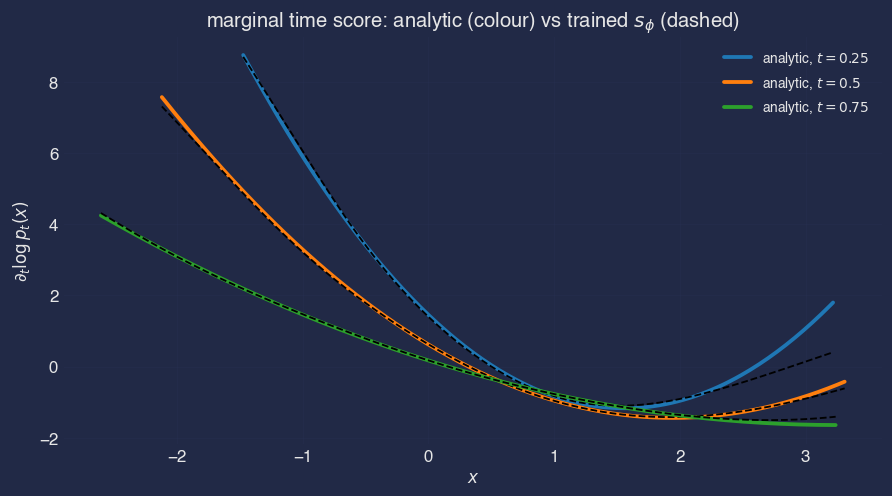

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.4), layout="constrained")
for t_eval, color in ((0.25, "tab:blue"), (0.5, "tab:orange"), (0.75, "tab:green")):
    a = schedule.alpha(torch.tensor(t_eval))
    s = schedule.sigma(torch.tensor(t_eval))
    m = (a * MU1).item()
    sd = float(torch.sqrt(a**2 * SIG1**2 + s**2))
    xs = torch.linspace(m - 3.0 * sd, m + 3.0 * sd, 201)
    tt = torch.full_like(xs, t_eval)
    with torch.no_grad():
        pred = s_phi(xs.unsqueeze(-1), tt).squeeze(-1)
    truth = marginal_time_score(xs, tt)
    w = torch.exp(marginal_logp(xs, tt))
    w = w / w.sum()
    rms = ((pred - truth).pow(2) * w).sum().sqrt()
    scale = (truth.pow(2) * w).sum().sqrt()
    print(f"t={t_eval}: weighted RMS {rms:.3f}  ({100 * rms / scale:.1f}% of signal)")
    ax.plot(xs, truth, color=color, lw=2.5, label=f"analytic, $t={t_eval}$")
    ax.plot(xs, pred, "--", color="k", lw=1.2)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\partial_t \log p_t(x)$")
ax.legend(fontsize=9)
ax.set_title("marginal time score: analytic (colour) vs trained $s_\\phi$ (dashed)")
plt.show()


### 6. The DRE payoff: integrate the net, get log density ratios

$\log[p_{t_1}(x)/p_{t_0}(x)] = \int_{t_0}^{t_1} s_\phi(x,\tau)\,d\tau$ —
a trained time score is a *continuum of density ratios*.  This is precisely
the identity that turns a parameter-path time score into per-event likelihood
information.


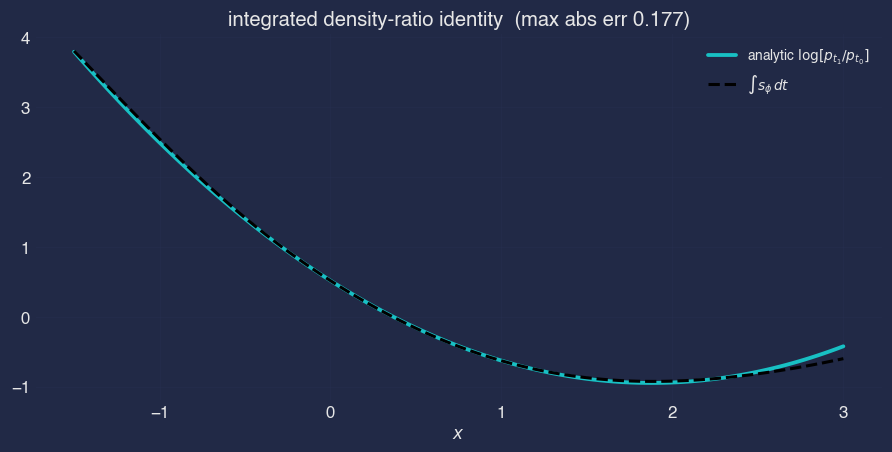

In [24]:
t0, t1 = 0.15, 0.9
taus = torch.linspace(t0, t1, 201)
xs = torch.linspace(-1.5, 3.0, 121)

with torch.no_grad():
    grid_pred = torch.stack(
        [s_phi(xs.unsqueeze(-1), torch.full_like(xs, t)).squeeze(-1)
         for t in taus.tolist()]
    )
integral = torch.trapezoid(grid_pred, taus, dim=0)
truth = marginal_logp(xs, torch.full_like(xs, t1)) - marginal_logp(
    xs, torch.full_like(xs, t0)
)

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(xs, truth, lw=2.5, label="analytic $\\log[p_{t_1}/p_{t_0}]$")
ax.plot(xs, integral, "--", lw=2, color="k", label=r"$\int s_\phi\, dt$")
ax.set_xlabel("$x$")
ax.legend(fontsize=9)
err = (integral - truth).abs().max()
ax.set_title(f"integrated density-ratio identity  (max abs err {err:.3f})")
plt.show()


## Where this plugs into parameter-flow

- **`CTSMJointScore`** wraps a net like the one above with the
  `ParameterPath` used in training: invert the path ($\theta \to s$), and
  the time score becomes the joint score $\partial_\theta\log p_\theta$
  feeding `parameter_flow_loss` as a frozen target — replacing `OracleScore`
  when no closed form exists.
- **Caveats carried in the docstrings**: the trained net is *path-locked*; for
  $\dim\Theta > 1$ only the directional score along the training path is
  recoverable.  And the spatial score should come from DSM
  (`DSMSpatialScore`), not from differentiating the time-score net (Eq. 32) —
  time scores may be well-fit while their $x$-gradients are not (Liu et al.
  2024).
- The slow-test twin:
  `tests/losses/test_score_matching.py::test_ctsm_recovers_marginal_time_score_and_density_ratio`.


### 7. Diagnostic cross-check: autograd through a conditional flow

When the model is a conditional flow with a tractable `log_prob(x, c=theta)`, `score_projection` gives the joint score by differentiating that log-density with respect to the conditioning parameter. This is not how the CTSM estimator above is trained, but it is a useful sanity check for the same object: $\partial_\theta \log p_\theta(x)$.

score_projection RMS error: 5.438e-16; max abs error: 1.776e-15


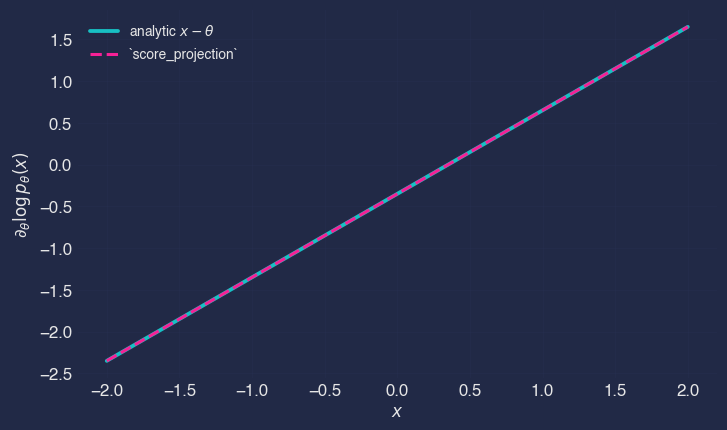

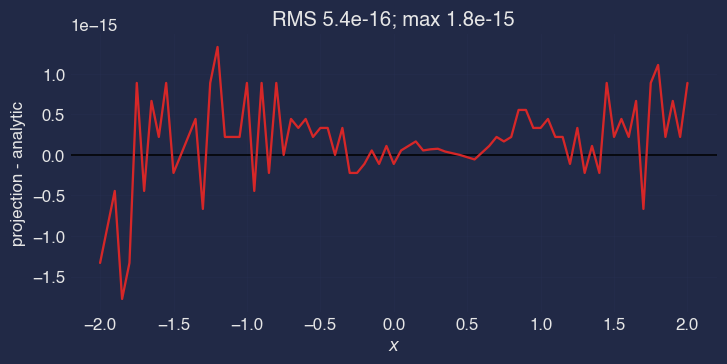

In [25]:
from nami import ExactDivergence, FlowMatching, RK4, StandardNormal
from nami.diagnostics import score_projection


class ContextShiftField:
    """Velocity equal to the context: the flow maps z -> z + theta."""

    event_ndim = 1

    def __call__(self, x, t, c=None):
        del t
        if c is None:
            return x * 0
        return x * 0 + c


dtype = torch.float64
flow = FlowMatching(
    ContextShiftField(),
    StandardNormal(event_shape=(1,), dtype=dtype),
    RK4(steps=8),
)()

x_probe = torch.linspace(-2.0, 2.0, 81, dtype=dtype).unsqueeze(-1)
theta_probe = torch.full_like(x_probe, 0.35)
projected = score_projection(
    flow,
    x_probe,
    theta_probe,
    estimator=ExactDivergence(create_graph=True),
)
truth = x_probe - theta_probe
residual = projected - truth

rms = residual.pow(2).mean().sqrt().item()
max_abs = residual.abs().max().item()
print(f"score_projection RMS error: {rms:.3e}; max abs error: {max_abs:.3e}")

fig, ax = plt.subplots(figsize=(6.5, 3.8), layout="constrained")
ax.plot(x_probe.squeeze(-1), truth.squeeze(-1), lw=2.5, label="analytic $x - \\theta$")
ax.plot(
    x_probe.squeeze(-1),
    projected.detach().squeeze(-1),
    "--",
    lw=2,
    label="`score_projection`",
)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\partial_\theta \log p_\theta(x)$")
ax.legend(fontsize=9)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 3.2), layout="constrained")
ax.axhline(0.0, color="k", lw=1)
ax.plot(x_probe.squeeze(-1), residual.detach().squeeze(-1), color="tab:red")
ax.set_xlabel("$x$")
ax.set_ylabel("projection - analytic")
ax.set_title(f"RMS {rms:.1e}; max {max_abs:.1e}")
plt.show()